LOAN APPROVAL CLASSIFICATION

In [1015]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter(action="ignore")
pd.set_option("display.float_format", "{:.0f}".format)

In [1016]:
df=pd.read_csv("loan_approval.csv")

In [1017]:
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


In [1018]:
df.shape

(2000, 8)

In [1019]:
df.columns
#points: A computed score or Risk Factor

Index(['name', 'city', 'income', 'credit_score', 'loan_amount',
       'years_employed', 'points', 'loan_approved'],
      dtype='str')

In [1020]:
df.describe()

,income,credit_score,loan_amount,years_employed,points
count,2000,2000,2000,2000,2000
mean,90586,574,25309,20,57
std,34488,161,14207,12,19
min,30053,300,1022,0,10
25%,61296,433,12749,10,45
50%,90388,576,25662,21,55
75%,120100,715,37380,31,70
max,149964,850,49999,40,100


In [1021]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   str    
 1   city            2000 non-null   str    
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   int64  
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   int64  
 6   points          2000 non-null   float64
 7   loan_approved   2000 non-null   bool   
dtypes: bool(1), float64(1), int64(4), str(2)
memory usage: 111.5 KB


In [1022]:
df["loan_approved"]=df["loan_approved"].astype(int)

In [1023]:
df.head(5)

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,0
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,0
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,0
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,0
4,Valerie Gray,Mariastad,66048,496,47174,4,25,0


In [1024]:
df.isnull().sum()

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

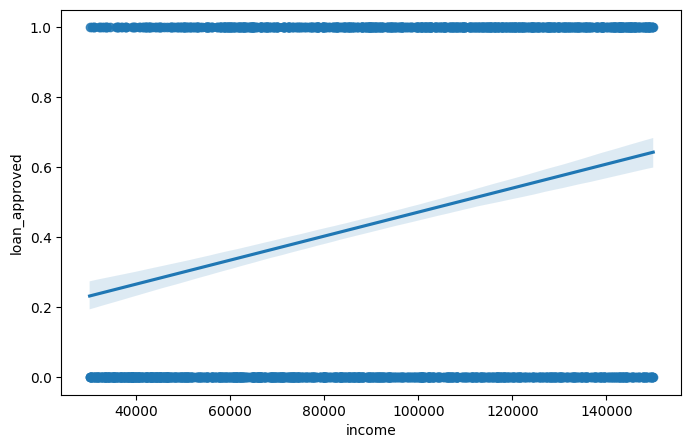

In [1025]:
plt.figure(figsize=(8,5))

sns.regplot(
    x="income", y="loan_approved", data=df,
)

plt.show()

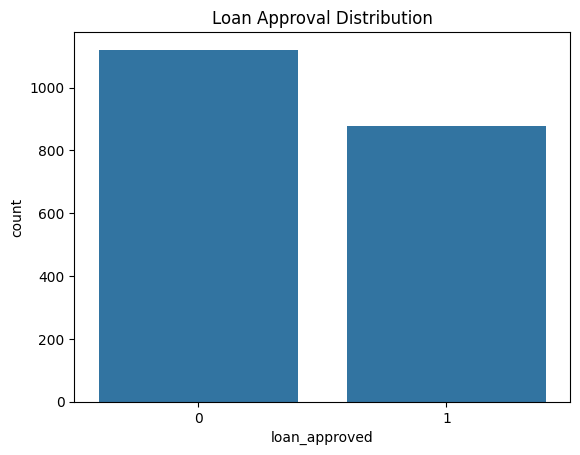

In [1026]:
sns.countplot(x="loan_approved", data=df)
plt.title("Loan Approval Distribution")
plt.show() #data balance

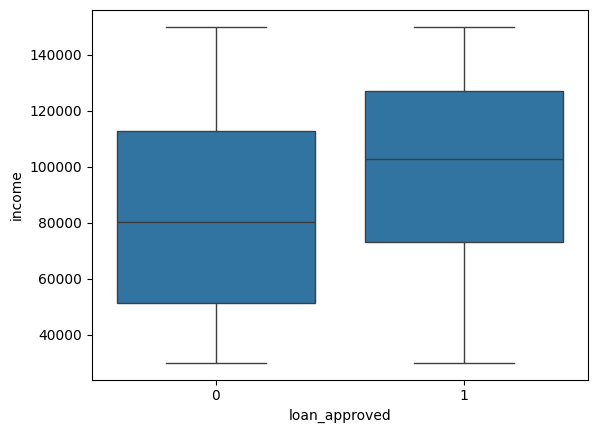

In [1027]:
sns.boxplot(x="loan_approved", y="income", data=df)
plt.show()

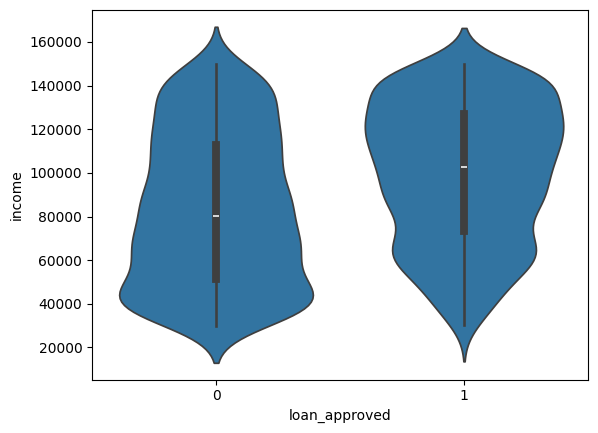

In [1028]:
#Good for understanding where values are concentrated.
sns.violinplot(x="loan_approved", y="income", data=df)
plt.show()

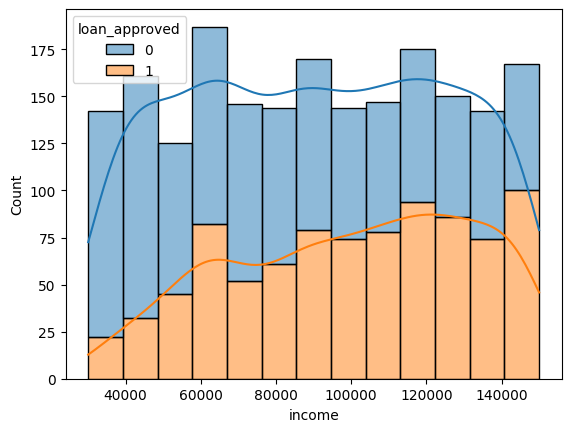

In [1029]:
sns.histplot(
    data=df,
    x="income",
    hue="loan_approved",
    kde=True,
    multiple="stack"
)
plt.show()
#Shows how the income distribution differs between approved and rejected applicants.

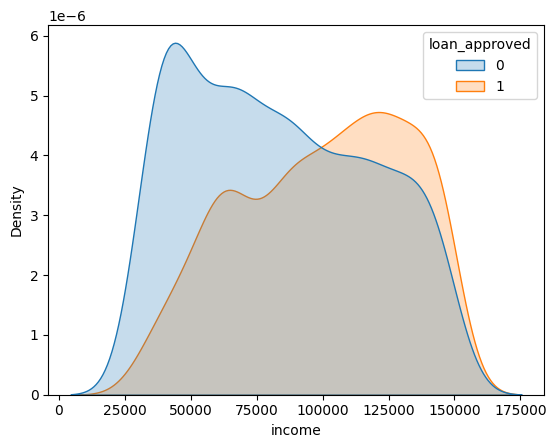

In [1030]:
sns.kdeplot(
    data=df,
    x="income",
    hue="loan_approved",
    fill=True
)
plt.show()
#Produces smooth curves to compare the distributions of the two classes.

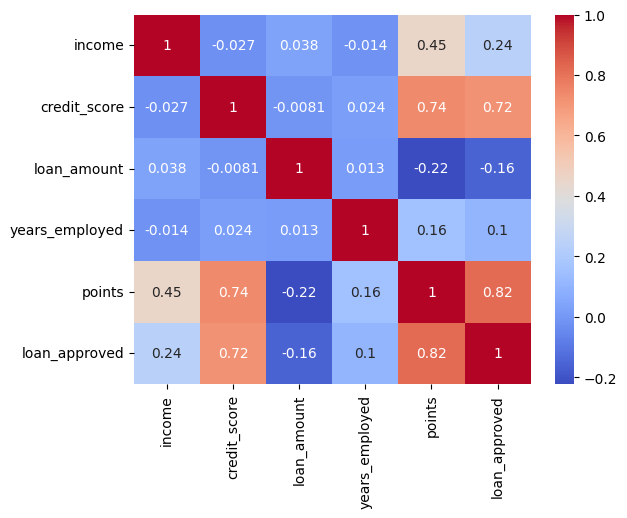

In [1031]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.show()

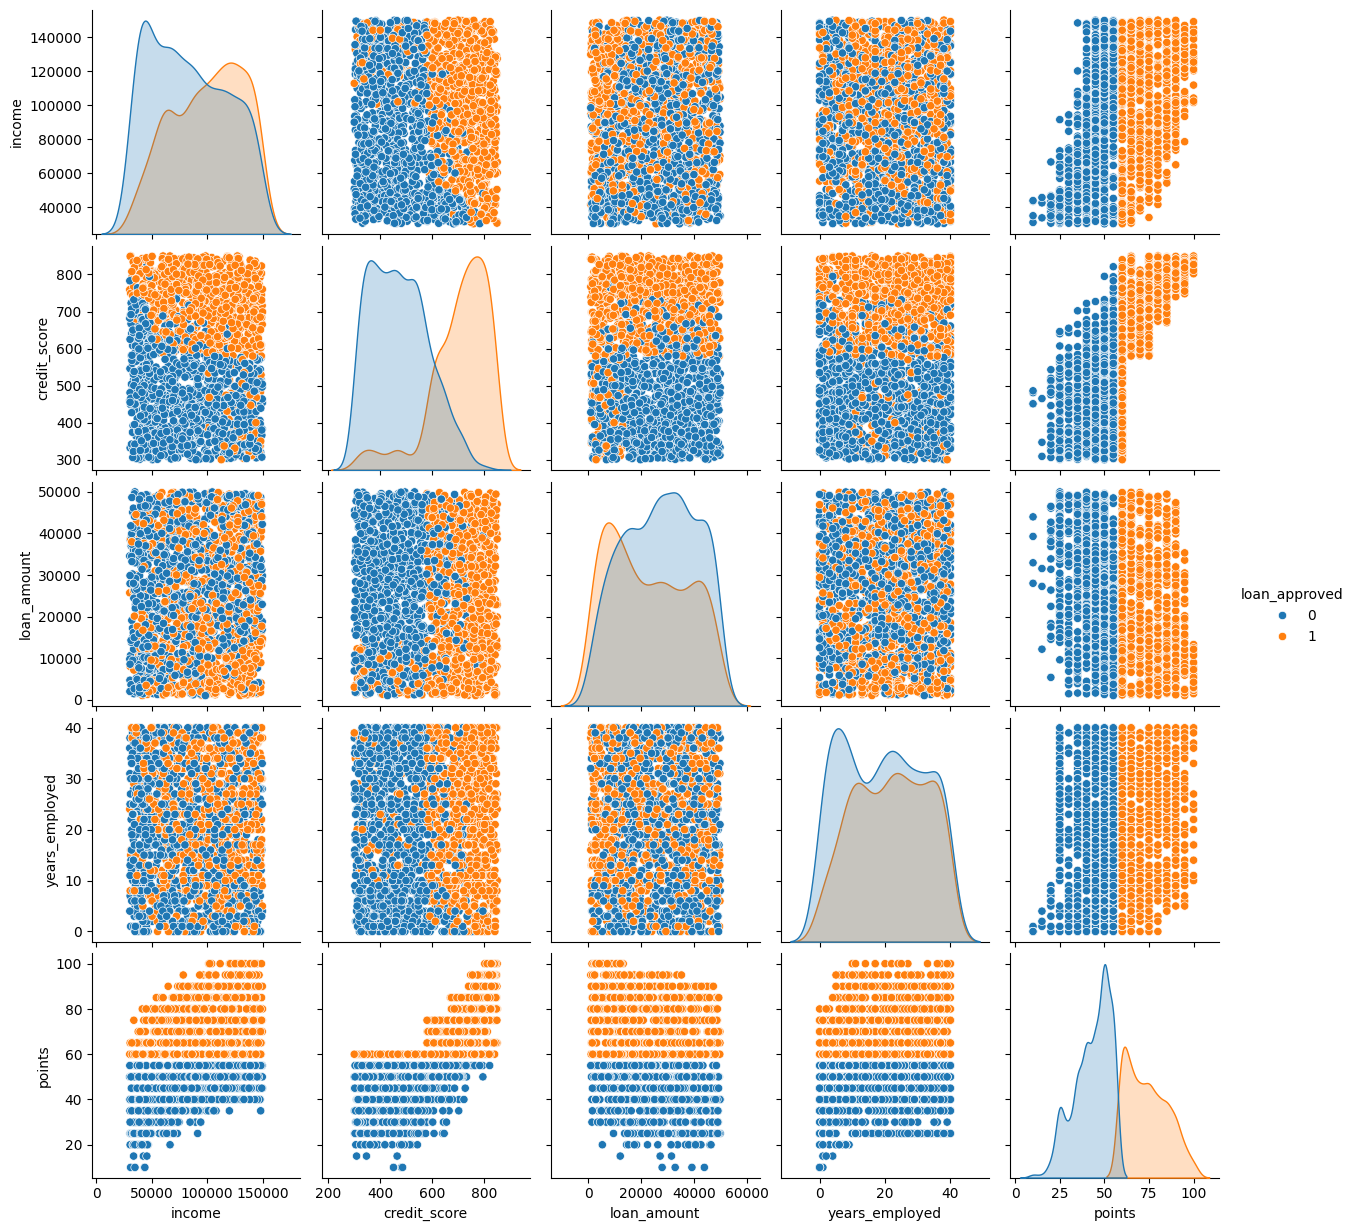

In [1032]:
sns.pairplot(
    df,
    hue="loan_approved"
)

In [1033]:
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,0
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,0
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,0
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,0
4,Valerie Gray,Mariastad,66048,496,47174,4,25,0


<Axes: xlabel='loan_approved', ylabel='credit_score'>

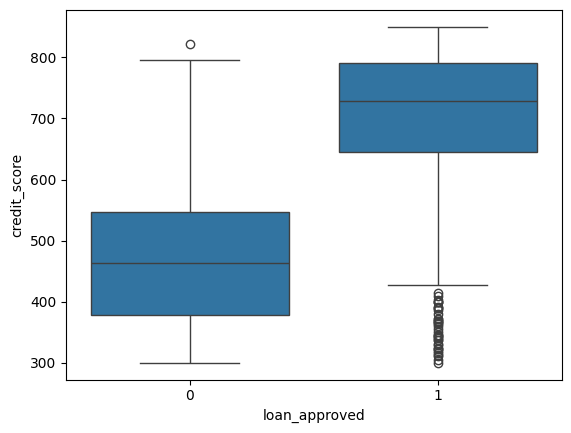

In [1034]:
sns.boxplot(x="loan_approved",y="credit_score",data=df)

In [1035]:
df[(df["credit_score"] <=430) & (df["loan_approved"]  ==1) & (df["income"] >=100000)]  #income is high and loan ammount low and risk point also low than approved loan when credit score is low.

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
15,Alec Hickman,Johnbury,107397,380,6613,31,60,1
23,David Leblanc,Mortonside,108907,400,4315,34,60,1
30,Timothy Walls,South Christineshire,101426,402,5801,34,60,1
34,Kathy King,North Cynthiaview,107236,345,1232,21,60,1
136,Michael Watkins,Brandonfurt,144867,356,1503,13,60,1
193,Ashley Allen,West Shannonberg,100381,399,4316,18,60,1
225,Angela Griffin,Christianshire,129943,414,5047,35,60,1
336,Krista Davis,Port Lauraville,115649,312,5041,14,60,1
337,Rodney Watson,New Brendaland,114696,322,5225,12,60,1
395,Jeffrey Jordan,Sanfordfurt,132676,304,3472,34,60,1


In [1036]:
df[(df["credit_score"] <=430) & (df["loan_approved"]  ==1) & (df["income"] <=100000)]  #no loan approved whose income is below 100000.


,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved


In [1037]:
df[(df["credit_score"] >=800) & (df["loan_approved"]  ==0) ]  # credit score high but income is medim but year joined very low that why loan not approved.

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
986,Matthew Richardson,North Christopherfort,45012,821,15741,1,55,0


In [1038]:
df[(df["income"] <=50000) & (df["loan_approved"]  ==1) & (df["years_employed"] <=10)] #i observed that if income is low and years of employee high than chances of loan_approved also

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
147,Nancy Williams,West Cassidy,48726,813,10886,3,65,1
163,Bobby Scott,New Shelby,48131,840,28738,7,60,1
312,Nicole Phillips,Port Rachaelbury,47342,806,26289,7,60,1
530,Brandon Montgomery,North Michaelberg,30464,849,8038,8,65,1
1246,Connie Gonzalez,Hernandezburgh,40641,808,19520,8,60,1
1607,Michael Marquez,Jamesmouth,48758,832,12364,7,65,1
1819,Crystal Wilkinson,Proctorview,34288,819,20127,8,60,1
1997,Brandon Meyer,East Haley,41957,763,16752,5,60,1


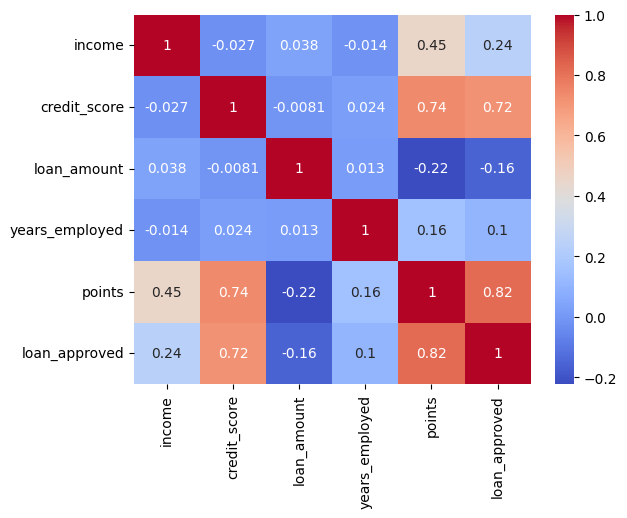

In [1039]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.show()  #but here year_employee correlation is 0.1 but high related to loan approval.

<Axes: xlabel='loan_approved', ylabel='loan_amount'>

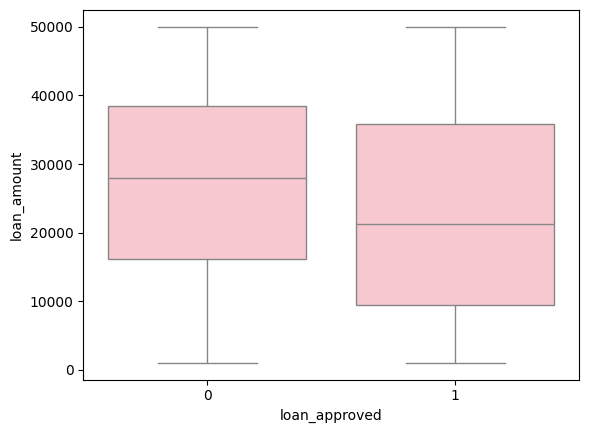

In [1040]:
sns.boxplot(x="loan_approved",y="loan_amount",data=df,color="pink")  #loan amount high chances of loan approved also decrease that why correlation show -0.16.

In [1041]:
df[(df["income"] <=50000) & (df["loan_approved"]  ==1) & (df["loan_amount"] >=30000)]  #if loan approved when loan amount high than other feature are good which help to approved loan

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
79,Phillip Obrien,Port Alexandra,36006,761,30014,19,60,1
166,Kenneth Lopez,New Theresaland,41915,838,36656,32,65,1
411,Michael Brown,North Robert,37492,794,38286,28,60,1
424,Tina Taylor,Smithton,38981,743,39346,30,60,1
490,Benjamin Phillips,Port Williamview,31025,850,38676,16,65,1
1113,Keith Obrien,North Theresastad,32260,795,41239,38,60,1
1202,Matthew Douglas,West Shawnaborough,39710,806,47219,22,65,1
1236,Raymond Hall,Petersonshire,37894,830,35419,37,65,1
1567,Chelsea Norris,Lake Bradleyshire,42903,745,37630,31,60,1
1579,Kyle Cooper,Jaredchester,36028,789,42629,39,60,1


<Axes: xlabel='loan_approved', ylabel='years_employed'>

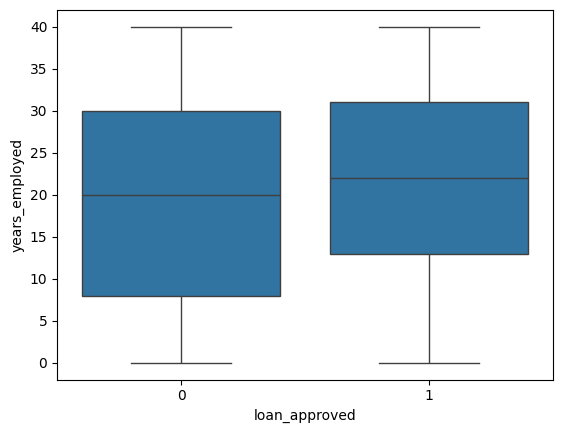

In [1042]:
sns.boxplot(x="loan_approved",y="years_employed",data=df)

<Axes: xlabel='years_employed', ylabel='loan_approved'>

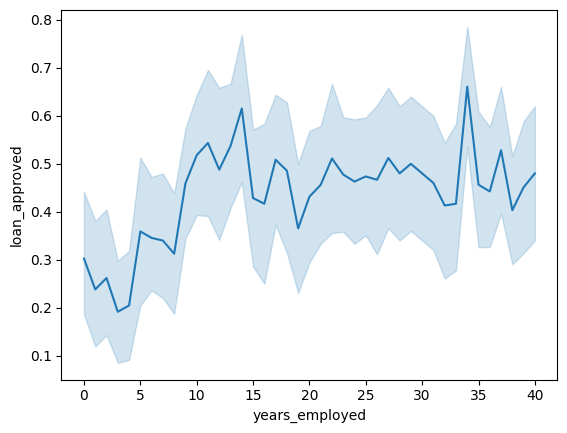

In [1043]:
sns.lineplot(x="years_employed",y="loan_approved",data=df)

<Axes: xlabel='years_employed', ylabel='loan_approved'>

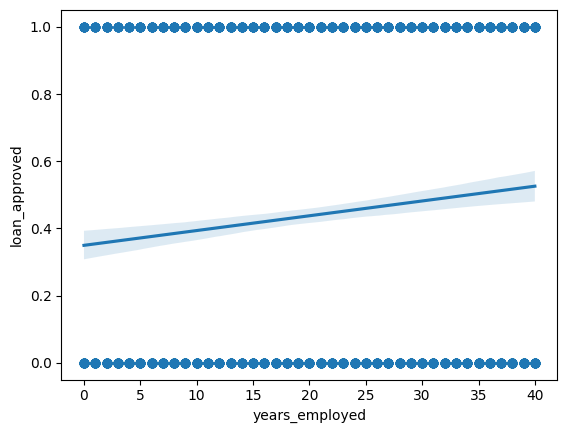

In [1044]:
sns.regplot(x="years_employed",y="loan_approved",data=df)  # year of employment high than loan approved chance high.


<Axes: xlabel='points', ylabel='loan_approved'>

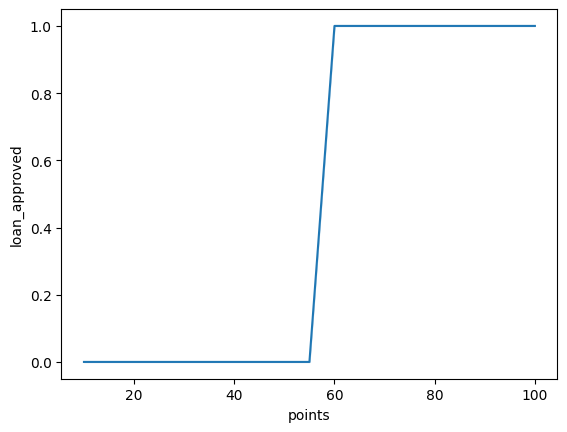

In [1045]:
sns.lineplot(x="points",y="loan_approved",data=df)

<Axes: xlabel='loan_approved', ylabel='points'>

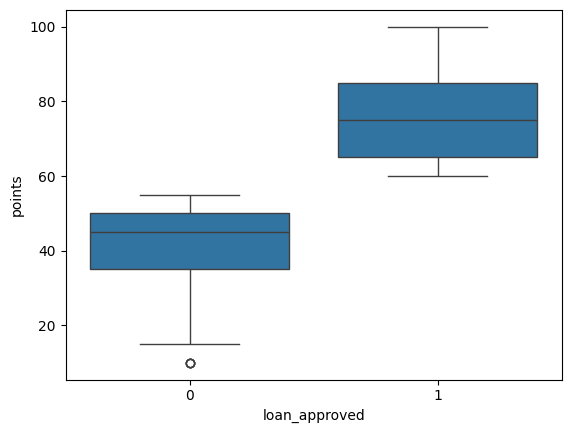

In [1046]:
sns.boxplot(x="loan_approved",y="points",data=df)  # one outlier which is approximitly points 0  and loan not approved and uppere 60 and median 70 points are good to get loan approved

In [1047]:
#for city are important are not we check

print(df["city"].value_counts())

print(df["city"].nunique())  # 1882 city are very big so we drop this columns city.

city
North Joseph        4
North Michael       3
Port Michael        3
Christinachester    3
West Melissa        3
                   ..
Robertton           1
New Frank           1
East Haley          1
Adamland            1
New Nathantown      1
Name: count, Length: 1882, dtype: int64
1882


In [1048]:
df.head(19)

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,0
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,0
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,0
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,0
4,Valerie Gray,Mariastad,66048,496,47174,4,25,0
5,Darren Roberts,Port Jesseville,62098,689,19217,29,65,1
6,Holly Wood,Lake Joseph,59256,373,40920,40,35,0
7,Nicholas Martin,Nelsonside,48289,524,45866,20,25,0
8,Patty Perez,Port Leslieview,126530,367,14826,36,55,0
9,Emily Rios,Wilkersonmouth,43434,446,18359,8,20,0


In [1049]:
df=df.drop(columns=["name","city"])  # not important for loan prediction.

model process

In [1050]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   income          2000 non-null   int64  
 1   credit_score    2000 non-null   int64  
 2   loan_amount     2000 non-null   int64  
 3   years_employed  2000 non-null   int64  
 4   points          2000 non-null   float64
 5   loan_approved   2000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 93.9 KB


In [1053]:
X=df.drop(columns="loan_approved")
y=df["loan_approved"]

In [1054]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(
    X,y,test_size=0.20,random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [1056]:
model_log=LogisticRegression()
model_log.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [1057]:
y_pred=model_log.predict(X_test)

In [1058]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
print("LOGISTIC REGRATION")
#print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

LOGISTIC REGRATION
Precision: 0.8478260869565217
Recall   : 0.8524590163934426
F1 Score : 0.8501362397820164
ROC AUC  : 0.8617133791644632

Confusion Matrix
[[189  28]
 [ 27 156]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       217
           1       0.85      0.85      0.85       183

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.86      0.86      0.86       400



In [1065]:
X=df.drop(columns=["loan_approved","points"])  #points leak faeture data point 60 avove approve loan if not than not appprove
y=df["loan_approved"]

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(
    X,y,test_size=0.20,random_state=42
)

In [1066]:
model_rf=RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    min_samples_leaf=2,
    min_samples_split=2,
    max_depth=None
    )

model_rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [1067]:
y_pred=model_rf.predict(X_test)

In [1068]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
print("Random Forest Classifier")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Random Forest Classifier
Accuracy : 0.9675
Precision: 0.9619565217391305
Recall   : 0.9672131147540983
F1 Score : 0.9645776566757494
ROC AUC  : 0.9674775251189847

Confusion Matrix
[[210   7]
 [  6 177]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       217
           1       0.96      0.97      0.96       183

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



In [1088]:
import joblib

joblib.dump(model_rf,"loan_approve.pkl")

['loan_approve.pkl']

In [1069]:
X.columns

Index(['income', 'credit_score', 'loan_amount', 'years_employed'], dtype='str')

In [1086]:
print(model_rf.predict([[107000,380,10000,29]]))

[1]


In [1080]:
df[(df["credit_score"] <=500) & (df["loan_approved"]==1)]

,income,credit_score,loan_amount,years_employed,points,loan_approved
15,107397,380,6613,31,60,1
23,108907,400,4315,34,60,1
30,101426,402,5801,34,60,1
34,107236,345,1232,21,60,1
136,144867,356,1503,13,60,1
...,...,...,...,...,...,...
1814,139273,447,6528,10,60,1
1859,138765,475,7606,27,60,1
1866,143992,400,9828,23,60,1
1951,101874,468,4504,13,60,1


In [ ]:
print(df.groupby("loan_approved")["points"].describe())

               count  mean  std  min  25%  50%  75%  max
loan_approved                                           
0               1121    43   10   10   35   45   50   55
1                879    74   11   60   65   75   85  100


In [ ]:
from sklearn.tree import DecisionTreeClassifier

X = df[["points"]]
y = df["loan_approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

print(model.score(X_test, y_test))  #point alone decide if point above 60 than approve loan else not

1.0


In [ ]:
df[(df["points"] < 60) & (df["loan_approved"]==1)]

,income,credit_score,loan_amount,years_employed,points,loan_approved


In [ ]:
df["points"].isnull().sum()

np.int64(0)

In [ ]:
pd.crosstab(df["points"] >= 60, df["loan_approved"])

loan_approved,0,1
points,,
False,1121,0
True,0,879


In [ ]:
df.shape

(2000, 6)